# DSAI 490 — Assignment 1: Representation Learning with Autoencoders

This notebook documents the full experiment pipeline for training and analyzing
Autoencoder (AE) and Variational Autoencoder (VAE) models on the Medical MNIST dataset.

**Dataset:** Medical MNIST — 6 anatomical regions, 64×64 grayscale images  
**Models:** One AE + one VAE per region = 12 models total  
**Latent space:** 2D for direct visualization  

## 0. Setup

In [1]:
import os
import sys

# Make sure src/ is importable from the notebook
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from src.data_processing import build_region_datasets, ANATOMICAL_REGIONS
from src.model import Autoencoder, VAE
from src.utils import (
    plot_loss_curves,
    plot_vae_loss_curves,
    plot_reconstructions,
    plot_latent_space,
    plot_generated_samples,
    plot_denoising,
)

print('TensorFlow version:', tf.__version__)
print('Regions:', ANATOMICAL_REGIONS)

TensorFlow version: 2.21.0
Regions: ['AbdomenCT', 'BreastMRI', 'ChestCT', 'CXR', 'Hand', 'HeadCT']


## 1. Load Dataset

In [2]:
# Load all datasets — one tf.data pipeline per region
datasets = build_region_datasets('../data/raw')

# Print summary
print(f"{'Region':<15} {'Train':>8} {'Val':>8} {'Test':>8}")
print('-' * 42)
for region in ANATOMICAL_REGIONS:
    d = datasets[region]
    print(f"{region:<15} {d['n_train']:>8} {d['n_val']:>8} {d['n_test']:>8}")


=== Loading Medical MNIST Dataset ===
  [AbdomenCT] → 10000 images found
  [BreastMRI] → 8954 images found
  [ChestCT] → 10000 images found
  [CXR] → 10000 images found
  [Hand] → 2449 images found
  [HeadCT] → 10000 images found
  [AbdomenCT] split → train: 7000 | val: 1500 | test: 1500
  [BreastMRI] split → train: 6267 | val: 1343 | test: 1344
  [ChestCT] split → train: 7000 | val: 1500 | test: 1500
  [CXR] split → train: 7000 | val: 1500 | test: 1500
  [Hand] split → train: 1714 | val: 367 | test: 368
  [HeadCT] split → train: 7000 | val: 1500 | test: 1500
=== Dataset Ready ===

Region             Train      Val     Test
------------------------------------------
AbdomenCT           7000     1500     1500
BreastMRI           6267     1343     1344
ChestCT             7000     1500     1500
CXR                 7000     1500     1500
Hand                1714      367      368
HeadCT              7000     1500     1500


## 2. Visualize Raw Data Samples

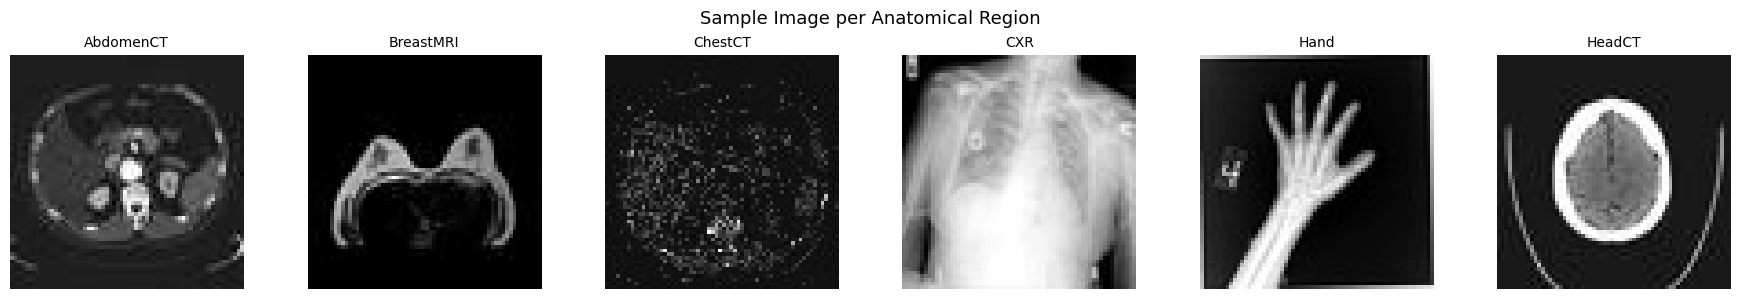

In [3]:
# Show one sample image from each anatomical region
fig, axes = plt.subplots(1, len(ANATOMICAL_REGIONS), figsize=(18, 3))

for ax, region in zip(axes, ANATOMICAL_REGIONS):
    for batch in datasets[region]['test'].take(1):
        img = batch[0, :, :, 0].numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(region, fontsize=10)
    ax.axis('off')

plt.suptitle('Sample Image per Anatomical Region', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/dataset_samples.png', dpi=150)
plt.show()

## 3. Load Trained Models

In [9]:
# Load all 12 saved models from models/
from src.model import Autoencoder, VAE, Encoder, Decoder, VAEEncoder

custom_objects = {
    "Autoencoder": Autoencoder,
    "VAE": VAE,
    "Encoder": Encoder,
    "Decoder": Decoder,
    "VAEEncoder": VAEEncoder,
}

models = {}

for region in ANATOMICAL_REGIONS:
    ae_path  = f'../models/{region}_ae_v1.keras'
    vae_path = f'../models/{region}_vae_v1.keras'

    models[region] = {
        'ae':  tf.keras.models.load_model(ae_path, custom_objects=custom_objects),
        'vae': tf.keras.models.load_model(vae_path, custom_objects=custom_objects),
    }
    print(f'  [{region}] loaded AE + VAE')

print(f'\nAll {len(models)} regions loaded.')


  [AbdomenCT] loaded AE + VAE
  [BreastMRI] loaded AE + VAE
  [ChestCT] loaded AE + VAE
  [CXR] loaded AE + VAE
  [Hand] loaded AE + VAE
  [HeadCT] loaded AE + VAE

All 6 regions loaded.


## 4. Reconstruction Analysis

In [10]:
# AE Reconstructions — all regions
for region in ANATOMICAL_REGIONS:
    plot_reconstructions(
        models[region]['ae'],
        datasets[region]['test'],
        region, 'AE', save=True
    )
    plt.show()

  Saved: figures\AbdomenCT_AE_reconstructions.png
  Saved: figures\BreastMRI_AE_reconstructions.png
  Saved: figures\ChestCT_AE_reconstructions.png
  Saved: figures\CXR_AE_reconstructions.png
  Saved: figures\Hand_AE_reconstructions.png
  Saved: figures\HeadCT_AE_reconstructions.png


In [11]:
# VAE Reconstructions — all regions
for region in ANATOMICAL_REGIONS:
    plot_reconstructions(
        models[region]['vae'],
        datasets[region]['test'],
        region, 'VAE', save=True
    )
    plt.show()

  Saved: figures\AbdomenCT_VAE_reconstructions.png
  Saved: figures\BreastMRI_VAE_reconstructions.png
  Saved: figures\ChestCT_VAE_reconstructions.png
  Saved: figures\CXR_VAE_reconstructions.png
  Saved: figures\Hand_VAE_reconstructions.png
  Saved: figures\HeadCT_VAE_reconstructions.png


## 5. Latent Space Visualization

In [12]:
# AE Latent Space
for region in ANATOMICAL_REGIONS:
    plot_latent_space(
        models[region]['ae'],
        datasets[region]['test'],
        region, 'AE', save=True
    )
    plt.show()

  Saved: figures\AbdomenCT_AE_latent_space.png
  Saved: figures\BreastMRI_AE_latent_space.png
  Saved: figures\ChestCT_AE_latent_space.png
  Saved: figures\CXR_AE_latent_space.png
  Saved: figures\Hand_AE_latent_space.png
  Saved: figures\HeadCT_AE_latent_space.png


In [13]:
# VAE Latent Space
for region in ANATOMICAL_REGIONS:
    plot_latent_space(
        models[region]['vae'],
        datasets[region]['test'],
        region, 'VAE', save=True
    )
    plt.show()

  Saved: figures\AbdomenCT_VAE_latent_space.png
  Saved: figures\BreastMRI_VAE_latent_space.png
  Saved: figures\ChestCT_VAE_latent_space.png
  Saved: figures\CXR_VAE_latent_space.png
  Saved: figures\Hand_VAE_latent_space.png
  Saved: figures\HeadCT_VAE_latent_space.png


## 6. VAE Sample Generation

In [14]:
# Generate new images from VAE prior N(0, I)
for region in ANATOMICAL_REGIONS:
    plot_generated_samples(
        models[region]['vae'],
        region, n_samples=16, save=True
    )
    plt.show()

  Saved: figures\AbdomenCT_VAE_generated_samples.png
  Saved: figures\BreastMRI_VAE_generated_samples.png
  Saved: figures\ChestCT_VAE_generated_samples.png
  Saved: figures\CXR_VAE_generated_samples.png
  Saved: figures\Hand_VAE_generated_samples.png
  Saved: figures\HeadCT_VAE_generated_samples.png


## 7. Denoising

In [15]:
# Denoising — AE and VAE side by side for each region
for region in ANATOMICAL_REGIONS:
    plot_denoising(
        models[region]['ae'],
        datasets[region]['test'],
        region, 'AE', noise_factor=0.3, save=True
    )
    plt.show()

    plot_denoising(
        models[region]['vae'],
        datasets[region]['test'],
        region, 'VAE', noise_factor=0.3, save=True
    )
    plt.show()

  Saved: figures\AbdomenCT_AE_denoising.png
  Saved: figures\AbdomenCT_VAE_denoising.png
  Saved: figures\BreastMRI_AE_denoising.png
  Saved: figures\BreastMRI_VAE_denoising.png
  Saved: figures\ChestCT_AE_denoising.png
  Saved: figures\ChestCT_VAE_denoising.png
  Saved: figures\CXR_AE_denoising.png
  Saved: figures\CXR_VAE_denoising.png
  Saved: figures\Hand_AE_denoising.png
  Saved: figures\Hand_VAE_denoising.png
  Saved: figures\HeadCT_AE_denoising.png
  Saved: figures\HeadCT_VAE_denoising.png


## 8. AE vs VAE Comparison

In [16]:
# Compute test reconstruction MSE for AE vs VAE per region
print(f"{'Region':<15} {'AE MSE':>10} {'VAE MSE':>10}")
print('-' * 38)

for region in ANATOMICAL_REGIONS:
    ae_losses, vae_losses = [], []

    for batch in datasets[region]['test']:
        # AE
        ae_recon = models[region]['ae'](batch, training=False)
        ae_losses.append(float(tf.reduce_mean(tf.square(batch - ae_recon))))

        # VAE
        vae_recon, _, _ = models[region]['vae'](batch, training=False)
        vae_losses.append(float(tf.reduce_mean(tf.square(batch - vae_recon))))

    ae_mse  = sum(ae_losses)  / len(ae_losses)
    vae_mse = sum(vae_losses) / len(vae_losses)
    print(f"{region:<15} {ae_mse:>10.4f} {vae_mse:>10.4f}")

Region              AE MSE    VAE MSE
--------------------------------------
AbdomenCT           0.0044     0.0048
BreastMRI           0.0583     0.0154
ChestCT             0.0029     0.0033
CXR                 0.0288     0.0269
Hand                0.0277     0.0278
HeadCT              0.0219     0.0218
